# Diabetes Hospital Readmission - EDA

This is the dataset for the classification half of Unit 1: ten years of clinical care records
from 130 US hospitals (UCI, loaded via `fairlearn`). The question: **which patients will be
readmitted within 30 days of discharge?** Early readmission is costly for hospitals and risky
for patients, so a usable early-warning model has real clinical value.

This walkthrough mirrors the real-estate series (`U1_RealEstate-1_EDA` onward), swapping a
regression target (price) for a **rare binary event** - which changes almost everything about
how we must evaluate models.

## Learning objectives

- Load the diabetes readmission data and identify the target and its class balance
- Recognize leakage columns that encode the outcome and must be dropped
- Distinguish literal `NaN` from an explicit `Unknown` category
- Compare readmission rates across clinical and demographic groups
- Name the downstream consequences of an 11% positive rate on split, metric, and model choice

## Background

This notebook assumes only pandas and basic plotting. It is the entry point of the classification
half of Unit 1 and the classification counterpart of `U1_RealEstate-1_EDA`.

The one number to carry forward is the **positive rate**: about 11% of encounters are readmissions
within 30 days. Every methodological choice in the rest of the spine — stratified splitting, F1
instead of accuracy, class weights, resampling — follows from it.

## This notebook covers

1. Loading the data
2. The target and its imbalance
3. Missingness, including the explicit `Unknown` level
4. Numeric features and demographics
5. Readmission rate by group
6. Correlations

**Prerequisites:** none — this is the first notebook of the classification walkthrough.

**Dataset:** `fairlearn.datasets.fetch_diabetes_hospital` — ten years of clinical records from 130
US hospitals (UCI), fetched at run time rather than read from disk.

**References:** https://fairlearn.org/main/api_reference/generated/fairlearn.datasets.fetch_diabetes_hospital.html

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from tqdm import tqdm

pd.set_option('display.max_columns',100)
pd.set_option('display.max_rows',100)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

# Shared course helpers (msds565_helpers.py lives in the repo root).
# Notebooks sit two folders below the root, so '../..' points back to it.
import sys
sys.path.append('../..')
import msds565_helpers as helpers

## 1. Load the data

In [2]:
from fairlearn.datasets import fetch_diabetes_hospital

data = fetch_diabetes_hospital(as_frame=True)
df = pd.concat([data.data, data.target], axis=1)

print(df.shape)
df.head()

(101766, 25)


,race,gender,age,discharge_disposition_id,admission_source_id,time_in_hospital,medical_specialty,num_lab_procedures,num_procedures,num_medications,primary_diagnosis,number_diagnoses,max_glu_serum,A1Cresult,insulin,change,diabetesMed,medicare,medicaid,had_emergency,had_inpatient_days,had_outpatient_days,readmitted,readmit_binary,readmit_30_days
0,Caucasian,Female,'30 years or younger',Other,Referral,1,Other,41,0,1,Diabetes,1,None,None,No,No,No,False,False,False,False,False,NO,0,0
1,Caucasian,Female,'30 years or younger','Discharged to Home',Emergency,3,Missing,59,0,18,Other,9,None,None,Up,Ch,Yes,False,False,False,False,False,>30,1,0
2,AfricanAmerican,Female,'30 years or younger','Discharged to Home',Emergency,2,Missing,11,5,13,Other,6,None,None,No,No,Yes,False,False,False,True,True,NO,0,0
3,Caucasian,Male,'30-60 years','Discharged to Home',Emergency,2,Missing,44,1,16,Other,7,None,None,Up,Ch,Yes,False,False,False,False,False,NO,0,0
4,Caucasian,Male,'30-60 years','Discharged to Home',Emergency,1,Missing,51,0,8,Other,5,None,None,Steady,Ch,Yes,False,False,False,False,False,NO,0,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 25 columns):
 #   Column                    Non-Null Count   Dtype   
---  ------                    --------------   -----   
 0   race                      101766 non-null  object  
 1   gender                    101766 non-null  object  
 2   age                       101766 non-null  object  
 3   discharge_disposition_id  101766 non-null  object  
 4   admission_source_id       101766 non-null  object  
 5   time_in_hospital          101766 non-null  int64   
 6   medical_specialty         101766 non-null  object  
 7   num_lab_procedures        101766 non-null  int64   
 8   num_procedures            101766 non-null  int64   
 9   num_medications           101766 non-null  int64   
 10  primary_diagnosis         101766 non-null  object  
 11  number_diagnoses          101766 non-null  int64   
 12  max_glu_serum             101766 non-null  object  
 13  A1Cresult                 101

## 2. The target: `readmit_30_days`

Two sibling columns (`readmitted`, `readmit_binary`) are alternative encodings of the same
outcome - they are dropped before modeling to avoid leakage. Note the **class imbalance**: this
single number shapes the entire pt-2 arc (stratified splits, resampling, class weights).

readmit_30_days
0    90409
1    11357
Name: count, dtype: int64

Positive rate: 11.2%


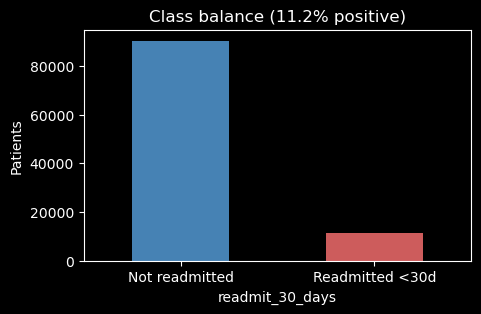

In [4]:
vc = df['readmit_30_days'].value_counts()
rate = df['readmit_30_days'].mean()
print(vc)
print(f"\nPositive rate: {rate:.1%}")

vc.plot(kind='bar', color=['steelblue','indianred'], figsize=(5,3))
plt.xticks([0,1], ['Not readmitted', 'Readmitted <30d'], rotation=0)
plt.ylabel('Patients')
plt.title(f'Class balance ({rate:.1%} positive)')
plt.show()

## 3. Missing and "Unknown" values

There are no literal NaNs, but several categoricals carry an explicit `Unknown` level - a
different kind of missingness that survives into modeling unless handled.

The distinction matters more than it looks. `df.isna().sum()` returns zero, so every automated
missingness check on this dataset passes — and yet information is genuinely absent, recorded as the
string `Unknown` in several categorical columns.

Because it is a string rather than a `NaN`, `Unknown` survives dummy-encoding and becomes its own
indicator column, which is arguably the honest outcome: "we do not know this patient's race" is a
real state of the record, and giving it a column lets the model use it rather than guessing. But it
must be a *decision*, not an accident. The alternative — imputing it to the most common level —
would fabricate data and erase the fact that it was missing.

Watch which columns carry it and how often. A column that is mostly `Unknown` carries little beyond
"this field was not recorded".


In [5]:
print("NaNs per column:", df.isna().sum().sum())

cat_cols = df.select_dtypes(exclude='number').columns
unknown_counts = (df[cat_cols].astype(str) == 'Unknown').sum()
unknown_counts[unknown_counts > 0]

NaNs per column: 0


race    2273
dtype: int64

## 4. Numeric features

Five clinical utilization counts - all right-skewed.

All five are **counts** of clinical activity — days in hospital, lab procedures, other procedures,
medications, diagnoses — and all five are right-skewed: most encounters are ordinary, a few involve
very sick patients with long stays and many procedures.

Skew has two consequences downstream. Distance-based models (KNN) and gradient descent both prefer
features on comparable, roughly symmetric scales, which is why `U1_Diabetes-3_Classification` scales
before fitting. And a long right tail means the extreme encounters exert outsized influence on any
squared-error quantity — the same argument that shaped the outlier filtering on the real-estate
side.


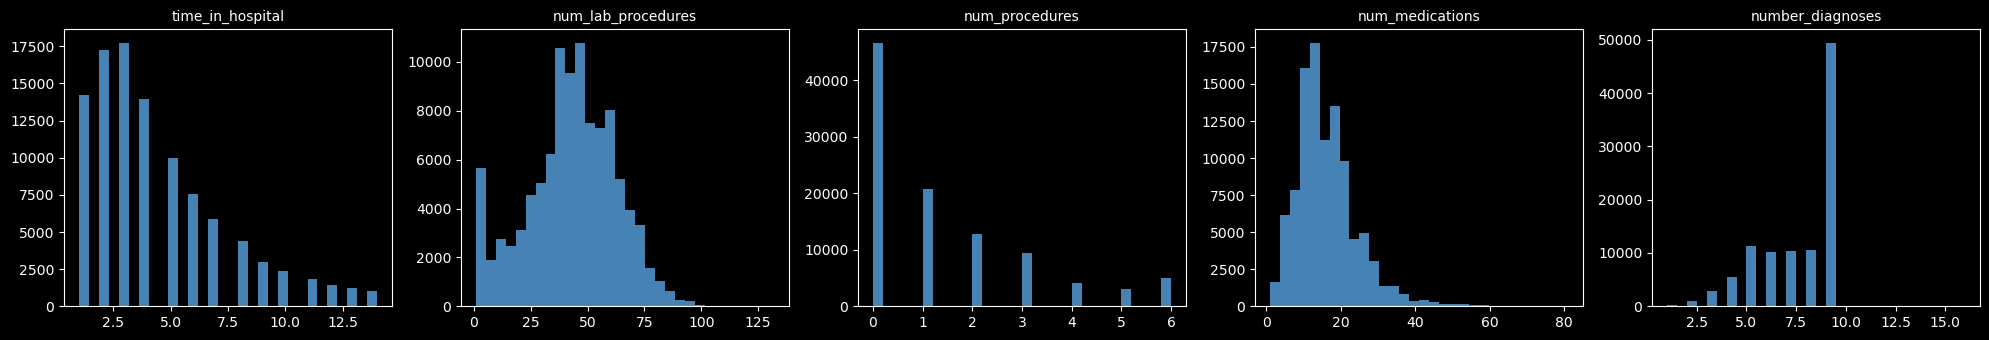

In [6]:
num_feats = ['time_in_hospital', 'num_lab_procedures', 'num_procedures',
             'num_medications', 'number_diagnoses']

fig, axes = plt.subplots(1, 5, figsize=(20, 3.5))
for ax, c in zip(axes, num_feats):
    ax.hist(df[c], bins=30, color='steelblue')
    ax.set_title(c, fontsize=10)
plt.tight_layout()
plt.show()

### 4.1 Demographics

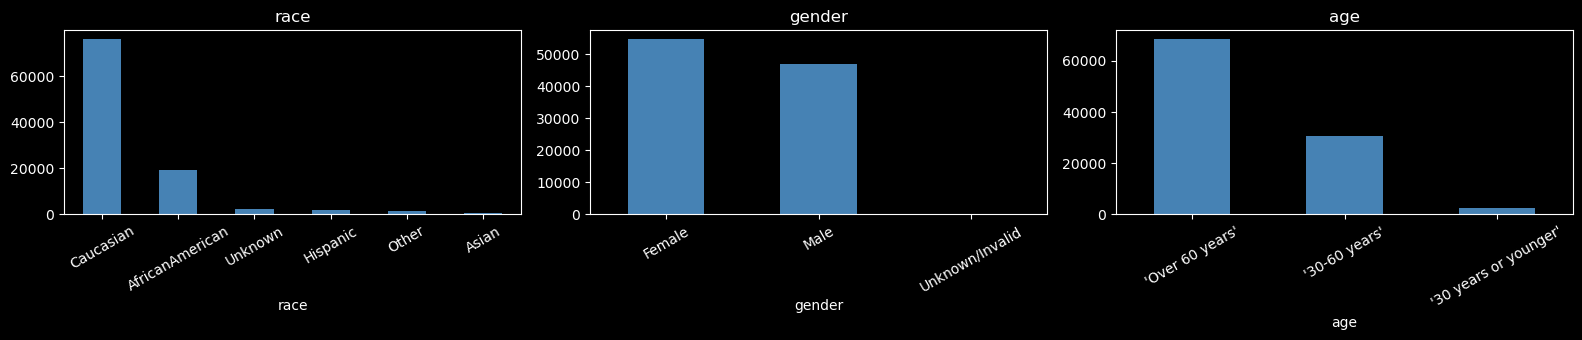

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 3.5))
for ax, c in zip(axes, ['race', 'gender', 'age']):
    df[c].value_counts().plot(kind='bar', ax=ax, color='steelblue')
    ax.set_title(c)
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

## 5. Readmission rate by group

The payoff plots: which groups run above or below the overall ~11% readmission rate? Prior
inpatient stays are the standout signal; the demographic gaps preview the fairness questions
in `U1_Diabetes-7_Interp`.

These are the plots that decide whether modeling is worth attempting. Each bar is a group's
readmission rate, and the vertical line is the ~11% overall rate — so the question each panel
answers is *does knowing this field move the estimate off the base rate?*

`had_inpatient_days` should be the standout: patients with prior inpatient stays readmit at well
above the base rate, which is clinically unsurprising and statistically the strongest single signal
in the dataset. A field whose bars all sit on the base-rate line carries no marginal information and
is a candidate for removal.

The demographic panels are doing double duty. They are ordinary EDA, and they are also the first
look at the question `U1_Diabetes-7_Interp` takes up formally: if readmission rates differ across
race or age groups, a model trained on this data will reproduce those differences, and whether that
is appropriate is a question about the world rather than about the model.


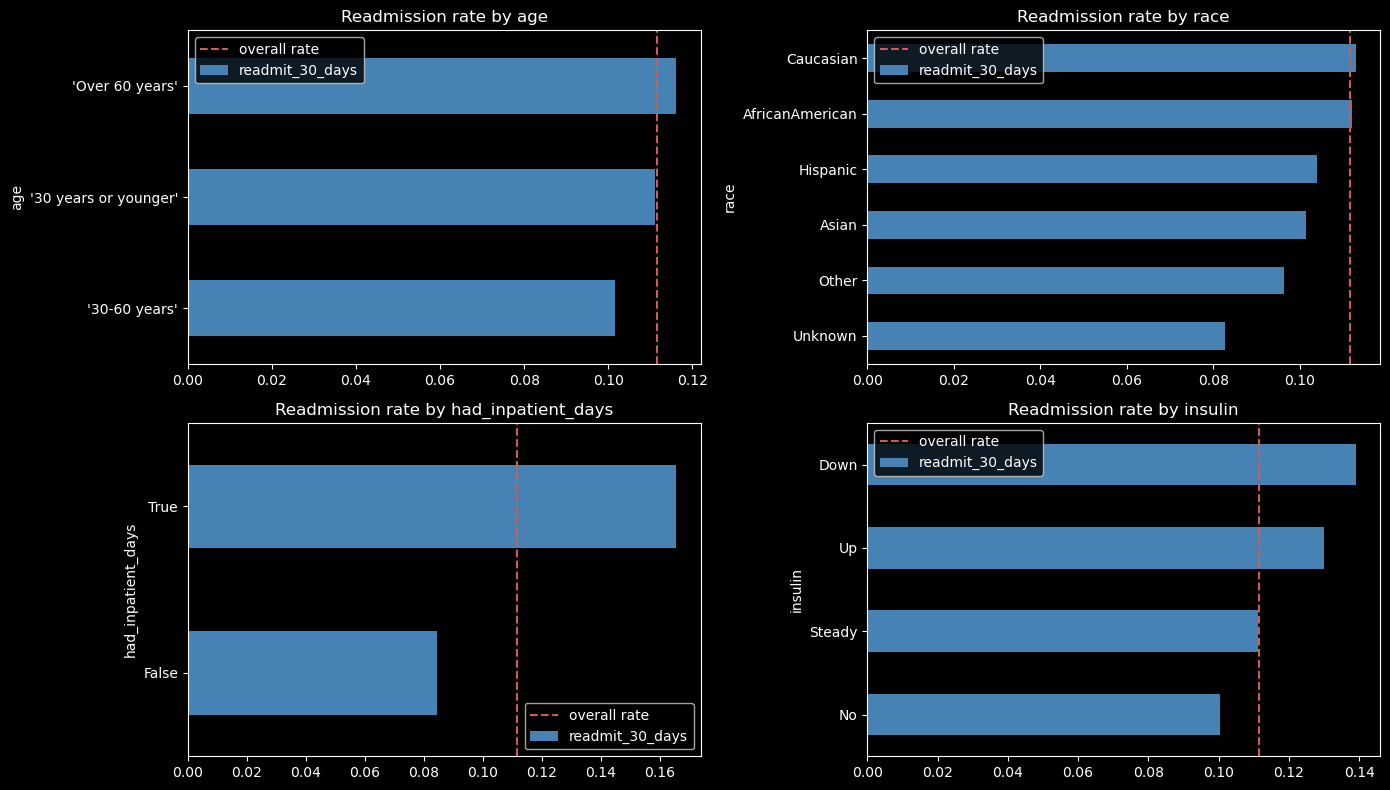

In [8]:
group_cols = ['age', 'race', 'had_inpatient_days', 'insulin']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, c in zip(axes.flatten(), group_cols):
    rates = df.groupby(c)['readmit_30_days'].mean().sort_values()
    rates.plot(kind='barh', ax=ax, color='steelblue')
    ax.axvline(df['readmit_30_days'].mean(), color='indianred',
               linestyle='--', label='overall rate')
    ax.set_title(f'Readmission rate by {c}')
    ax.legend()
plt.tight_layout()
plt.show()

## 6. Correlations (numeric features + target)

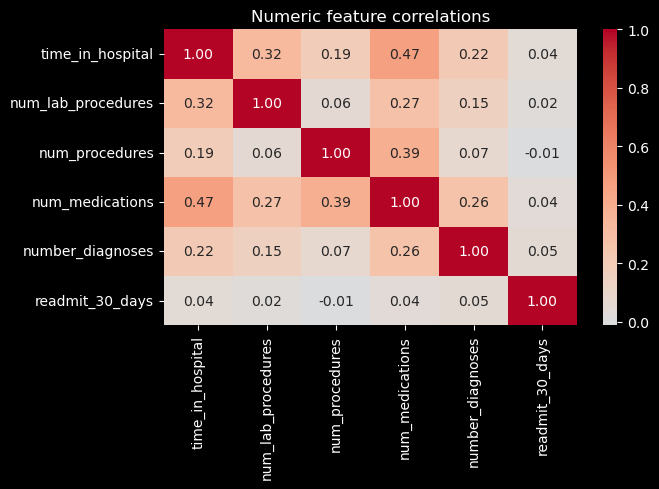

In [9]:
corr = df[num_feats + ['readmit_30_days']].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Numeric feature correlations')
plt.tight_layout()
plt.show()

## 7. Review

- **~11% positives.** Accuracy is a nearly useless metric here - a model that says "nobody is
  readmitted" scores 89%. This drives the imbalance section (`U1-7_Imbalance-*`,
  `U1_Diabetes-6_Imbalance`).
- **Utilization history dominates**: patients with prior inpatient days readmit at well above
  the base rate. No single numeric feature correlates strongly on its own.
- **Demographic gaps exist** (age and race groups differ in readmission rate) - whether the
  *model* treats groups fairly is audited in `U1_Diabetes-7_Interp`.
- Next: `U1_Diabetes-2_Preprocess` encodes the categoricals and saves the modeling CSV that
  notebooks 3-7 load.